# 05 — Final Model: Tuning, Frozen Decisions, and the One-Time Holdout Check

`03_model_extension.ipynb` found LightGBM the leading candidate (PR-AUC 0.240, ahead of Random
Forest and XGBoost), and `04_error_analysis.ipynb`'s error analysis found the three tree models
agree on 73% of fraud clients -- hard given the current features, not a model-choice problem --
and recommended proceeding to hyperparameter tuning rather than model-swapping or blind
ensembling.

This notebook is the last step: tune LightGBM, decide -- with evidence, not by default -- whether
a LightGBM+Random Forest ensemble is worth adopting, freeze the approach using only
cross-validation evidence from the development pool, and then evaluate the frozen pipeline
**exactly once** on the held-out `final_holdout` split. It also formally records the
leakage-features decision `01_eda.ipynb` Step 7 raised.

> **⚠️ Partial follow-through on 04's priority order.** This notebook went straight to tuning
> first (Steps 3-4) -- the "ahead of tuning" ordering `04_error_analysis.ipynb` recommended
> wasn't followed, and no relative/normalized feature versions were tried anywhere here. An
> earlier version of this notebook also re-checked `04`'s short-history blind spot on the
> untouched holdout, via a segment-level recall-at-a-fixed-top-10%-cutoff analysis broken out by
> invoice-count quintile and by region (a former Step 8). That analysis has been removed and
> stays removed -- it is not the same thing as the single illustrative example added to "So,
> what does this mean for the client?" below (one concrete snapshot of the curve already shown
> there, for scale, not a per-segment KPI table and not a recommended operating point). This
> notebook's own Limitations section already admits the underlying gap: "Any future iteration
> should prioritize new signal for short-history clients... over further tuning of this model
> family" -- i.e. this recommendation is still outstanding, and `04`'s blind spot is not
> re-verified against this holdout anywhere in this notebook.

## Imports and constants

In [1]:
from pathlib import Path

import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from joblib import dump
from lightgbm import LGBMClassifier
from sklearn import set_config
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

pd.set_option("display.max_columns", 100)
set_config(transform_output="pandas")

DATA_DIR = Path("data")
PROCESSED_DIR = DATA_DIR / "processed"
TRAINING_FEATURES_PATH = PROCESSED_DIR / "df_training.csv"
MODELS_DIR = Path("models")
FINAL_MODEL_PATH = MODELS_DIR / "final_model_pipeline.joblib"
FINAL_METADATA_PATH = MODELS_DIR / "final_model_metadata.json"

RSEED = 42
N_SPLITS = 5
FINAL_HOLDOUT_SIZE = 0.20

## Step 1 — Create the final-model holdout from df_training.csv

### Why a holdout, when 02-04 already used cross-validation?

Every notebook so far reported *cross-validated* scores -- honest in the sense that each fold's
predictions came from a model that never trained on those specific clients. But this project also
made a long chain of *decisions* by comparing CV scores against each other: which model family to
carry forward (`03`), and -- in this notebook -- which LightGBM preprocessing variant, which of
30 sampled hyperparameter combinations, and whether an ensemble earns its added complexity (Steps
2, 4, and 5 below). Each of those decisions keeps whichever option scored best on the *same* set
of CV folds. Even though no individual fold ever saw the client it scored, repeatedly picking the
best-of-many option on the same folds can flatter the winner a little -- it gets rewarded for
fitting those folds' particular noise, not only the true signal. A block of clients that none of
those decisions ever got to influence is the only way to get an honest read on how the *frozen*
pipeline -- not the search that produced it -- will actually perform on new clients.

### How the split is enforced

`train_test_split` on `df_training.csv`, stratified by `target`, with `FINAL_HOLDOUT_SIZE=0.20`
held out under a fixed seed. From here through Step 6, every cell below uses `development_data`
(the 80%) only. `final_holdout` (the 20%) is not touched again until Step 7, after every modeling
decision -- model family, preprocessing variant, hyperparameters, ensemble go/no-go -- has already
been frozen on development-pool evidence alone.

### The one caveat this can't fully clear

This is the cleanest look this project takes at held-out performance, but not a pristine first
one: `02_baseline_model.ipynb` already ran plain 5-fold CV over the *entire* labelled table,
before this 80/20 split existed -- so every row that ends up in `final_holdout` was already
inside some training fold during that earlier baseline check. No decision in *this* notebook
looks at `final_holdout` before Step 7, and nothing here reuses `02`'s fitted model, but it is
worth naming rather than presenting this as a completely virgin test set.

### What the holdout actually showed

Short version, expanded with real numbers in Step 7 and the Results section: the frozen model's
holdout PR-AUC came out *higher* than its development-pool CV PR-AUC, not lower -- the opposite
of what "the model was overfit to the tuning search" would look like.

In [2]:
df_training = pd.read_csv(TRAINING_FEATURES_PATH)
df_training["client_id"] = df_training["client_id"].astype("string")
df_training["target"] = df_training["target"].astype("int8")

expected_columns = {
    "client_id", "target",
    "invoice_count", "active_days", "mean_consumption", "zero_consumption_rate",
    "elec_share", "mean_invoice_gap_days", "backwards_index_rate", "meter_count",
    "mean_monthly_submission_index_delta", "backward_submission_rate",
    "large_mismatch_count", "reconciliation_gap_abs_mean",
    "client_catg", "disrict", "region",
}
missing_columns = sorted(expected_columns - set(df_training.columns))
if missing_columns:
    raise ValueError(f"{TRAINING_FEATURES_PATH} is missing required baseline columns: {missing_columns}")

# The EDA exports one complete labelled table. The final model creates its one-time
# holdout here, after loading that table, and never writes a separate holdout CSV.
development_data, final_holdout = train_test_split(
    df_training,
    test_size=FINAL_HOLDOUT_SIZE,
    random_state=RSEED,
    stratify=df_training["target"],
)

assert set(development_data["client_id"]).isdisjoint(final_holdout["client_id"])
overview = pd.DataFrame({
    "clients": [len(development_data), len(final_holdout)],
    "fraud_cases": [int(development_data["target"].sum()), int(final_holdout["target"].sum())],
    "fraud_rate": [development_data["target"].mean(), final_holdout["target"].mean()],
}, index=["development", "final_holdout"])
display(overview)

,clients,fraud_cases,fraud_rate
development,108394,6053,0.055843
final_holdout,27099,1513,0.055832


## Step 2 — Two preprocessing variants for LightGBM

Variant A is the identical `ColumnTransformer` every notebook so far has used: median-impute and
scale the 12 numeric features, one-hot encode `client_catg`/`disrict`/`region`. Variant B tests
`03_model_extension.ipynb`'s "cheap follow-up variant" suggestion: LightGBM can use categorical
columns natively (no one-hot) if they're typed as pandas `category` -- skipping one-hot removes
several dozen sparse dummy columns and lets LightGBM choose its own categorical splits. Random
Forest and XGBoost keep Variant A only -- 03's next-steps only proposed the native variant for
LightGBM, and this notebook doesn't retune them (see Step 3).

In [3]:
categorical_features = ["client_catg", "region", "disrict"]
numeric_features = [
    "invoice_count", "active_days", "mean_consumption", "zero_consumption_rate",
    "elec_share", "mean_invoice_gap_days", "backwards_index_rate", "meter_count",
    "mean_monthly_submission_index_delta", "backward_submission_rate",
    "large_mismatch_count", "reconciliation_gap_abs_mean",
]
model_features = numeric_features + categorical_features

X = development_data[model_features]
y = development_data["target"]
y_values = y.to_numpy()

# Variant A -- one-hot, identical to 02/03/04.
preprocessor_onehot = ColumnTransformer([
    ("numeric", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
])

# Variant B -- LightGBM-native categoricals: numeric branch imputes/scales, categoricals pass
# through untouched as pandas `category` dtype so LGBMClassifier auto-detects them.
X_native = X.copy()
for col in categorical_features:
    X_native[col] = X_native[col].astype("category")

preprocessor_native = ColumnTransformer([
    ("numeric", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric_features),
    ("categorical", "passthrough", categorical_features),
])

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RSEED)

## Step 3 — Fresh, same-environment reference numbers (untuned)

Recomputing LightGBM/Random Forest/XGBoost's untuned cross-validated numbers here, in this
notebook's own run, rather than quoting `03_model_extension.ipynb`'s historical results -- this
session already saw those drift slightly from a live rerun in `04_error_analysis.ipynb` (package
version differences), so a same-run baseline is what tuning lift should actually be measured
against. Random Forest and XGBoost stay untuned throughout this notebook: 03's own "Next steps"
say to keep them as references and revisit them only if justified, and 04's error analysis (73%
identical verdicts across all three models) didn't surface that justification.

In [4]:
scale_pos_weight = (y == 0).sum() / (y == 1).sum()

reference_specs = {
    "lightgbm_untuned": LGBMClassifier(class_weight="balanced", random_state=RSEED, n_jobs=-1, verbosity=-1),
    "random_forest": RandomForestClassifier(class_weight="balanced", random_state=RSEED, n_jobs=-1),
    "xgboost": XGBClassifier(
        scale_pos_weight=scale_pos_weight, eval_metric="logloss", random_state=RSEED, n_jobs=-1
    ),
}

reference_oof = {}
reference_rows = {}
for name, model in reference_specs.items():
    pipeline = Pipeline([("preprocess", preprocessor_onehot), ("model", model)])
    proba = cross_val_predict(pipeline, X, y, cv=cv, method="predict_proba")[:, 1]
    reference_oof[name] = proba
    reference_rows[name] = {
        "pr_auc": average_precision_score(y_values, proba),
        "roc_auc": roc_auc_score(y_values, proba),
    }
    print(f"done: {name}")

reference_summary = pd.DataFrame(reference_rows).T
display(reference_summary)

done: lightgbm_untuned


done: random_forest


done: xgboost


,pr_auc,roc_auc
lightgbm_untuned,0.237864,0.826622
random_forest,0.219811,0.810723
xgboost,0.221985,0.803202


## Step 4 — Hyperparameter tuning of LightGBM

`RandomizedSearchCV` rather than an exhaustive `GridSearchCV` -- cheaper for a search this wide --
scored on `average_precision`, same 5-fold CV/seed as everywhere else in this project.
`class_weight="balanced"` stays fixed (not searched), consistent with every other notebook's
methodology. Run once for each preprocessing variant from Step 2; the winner is whichever gets
the higher CV PR-AUC.

### Cached, so you don't pay for this twice

This search is the slow part of the notebook -- roughly 45 minutes for 30 draws x 2 preprocessing
variants x 5 folds. Step 8 below persists the winning `winning_variant`/`best_params` to
`models/final_model_metadata.json` right alongside the fitted `models/final_model_pipeline.joblib`.
If both files are already on disk, the cell below loads that frozen choice instead of re-running
`RandomizedSearchCV` -- Steps 5-8 only need `winning_variant`/`best_params`, not the search objects
themselves, so the rest of the notebook runs unchanged either way. Set `FORCE_RETUNE = True` in
the next cell (and rerun it) to force a fresh search regardless -- e.g. after widening
`param_distributions` above or after `df_training.csv` has changed since the cache was written.

In [5]:
param_distributions = {
    "model__n_estimators": [100, 200, 300, 500, 800],
    "model__num_leaves": [15, 31, 63, 127],
    "model__max_depth": [-1, 4, 6, 8, 10],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "model__min_child_samples": [5, 10, 20, 50, 100],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__reg_alpha": [0.0, 0.1, 1.0, 5.0],
    "model__reg_lambda": [0.0, 0.1, 1.0, 5.0],
}
N_SEARCH_ITER = 30

# Flip to True (and rerun this cell) to force a fresh RandomizedSearchCV even when a cached choice
# already exists on disk -- e.g. after widening param_distributions above, or after
# df_training.csv has changed since the cache was written.
FORCE_RETUNE = False


def tune_lightgbm(preprocessor, features, label):
    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", LGBMClassifier(class_weight="balanced", random_state=RSEED, n_jobs=-1, verbosity=-1)),
    ])
    search = RandomizedSearchCV(
        pipeline, param_distributions, n_iter=N_SEARCH_ITER, scoring="average_precision",
        cv=cv, random_state=RSEED, n_jobs=1, refit=True,
    )
    search.fit(features, y)
    print(f"{label}: best CV PR-AUC = {search.best_score_:.4f}")
    print(f"{label}: best params = {search.best_params_}")
    return search


# Step 8 persists the winning preprocessing variant and hyperparameters to
# final_model_metadata.json right alongside the fitted final_model_pipeline.joblib. If both are
# already on disk, load that frozen choice instead of re-running the ~45-minute search below --
# everything downstream (Steps 5-8) only needs winning_variant/best_params, not the
# RandomizedSearchCV objects themselves.
cached_metadata = None
if not FORCE_RETUNE and FINAL_MODEL_PATH.exists():
    if FINAL_METADATA_PATH.exists():
        with open(FINAL_METADATA_PATH) as f:
            cached_metadata = json.load(f)
    else:
        print(f"{FINAL_MODEL_PATH} exists but {FINAL_METADATA_PATH} is missing -- running a fresh search.")

if cached_metadata is not None:
    winning_variant = cached_metadata["winning_variant"]
    best_params = cached_metadata["best_params"]
    print(
        f"Loaded frozen hyperparameters from {FINAL_METADATA_PATH} -- skipping the "
        "RandomizedSearchCV over both preprocessing variants.\n"
        f"Winning variant: {winning_variant}\n"
        f"Best params:     {best_params}\n"
        "(Set FORCE_RETUNE = True above and rerun this cell to search again from scratch.)"
    )
else:
    search_onehot = tune_lightgbm(preprocessor_onehot, X, "LightGBM (one-hot)")
    search_native = tune_lightgbm(preprocessor_native, X_native, "LightGBM (native categorical)")

    tuning_results = pd.DataFrame({
        "variant": ["one-hot", "native categorical"],
        "cv_pr_auc": [search_onehot.best_score_, search_native.best_score_],
    }).set_index("variant")
    print("\nTuned LightGBM: preprocessing variant comparison")
    display(tuning_results)
    print(f"\nUntuned LightGBM baseline (Step 3): {reference_rows['lightgbm_untuned']['pr_auc']:.4f}")

    winning_search = search_onehot if search_onehot.best_score_ >= search_native.best_score_ else search_native
    winning_variant = "one-hot" if winning_search is search_onehot else "native categorical"
    best_params = {k.split("__", 1)[1]: v for k, v in winning_search.best_params_.items()}
    print(f"\nWinning variant: {winning_variant} (best params: {winning_search.best_params_})")

winning_features = X if winning_variant == "one-hot" else X_native
winning_preprocessor = preprocessor_onehot if winning_variant == "one-hot" else preprocessor_native

# One canonical "final model pipeline" template -- the single place that defines what "the final
# model" is. Every later step that needs this exact recipe (the OOF check right below, the
# development-pool fit Step 7 evaluates on the holdout, and Step 8's deployment refit) clones this
# same object rather than separately rebuilding an equivalent Pipeline by hand. It is deliberately
# left unfitted here: each consumer fits its own clone() on the data it actually needs to see.
final_model_pipeline = Pipeline([
    ("preprocess", winning_preprocessor),
    ("model", LGBMClassifier(
        class_weight="balanced", random_state=RSEED, n_jobs=-1, verbosity=-1, **best_params
    )),
])

# Fit once on the development pool -- this is what Step 7 evaluates on the holdout. Needed either
# way (fresh search or cached choice), so it's built explicitly here rather than reused from
# RandomizedSearchCV's refit=True estimator, which only exists on the non-cached path.
final_model_fitted_dev = clone(final_model_pipeline)
final_model_fitted_dev.fit(winning_features, y)

# For an honest out-of-fold score here (needed for the ensemble check in Step 5), fit a *separate*
# clone of final_model_pipeline via cross_val_predict -- using final_model_fitted_dev.predict_proba(X)
# directly would be in-sample, since that estimator was already fit on all of (X, y).
tuned_lightgbm_oof = cross_val_predict(
    clone(final_model_pipeline), winning_features, y, cv=cv, method="predict_proba"
)[:, 1]
tuned_lightgbm_pr_auc = average_precision_score(y_values, tuned_lightgbm_oof)
tuned_lightgbm_roc_auc = roc_auc_score(y_values, tuned_lightgbm_oof)
print(
    f"\nTuned LightGBM ({winning_variant}) OOF: "
    f"PR-AUC={tuned_lightgbm_pr_auc:.4f}, ROC-AUC={tuned_lightgbm_roc_auc:.4f}"
)

Loaded frozen hyperparameters from models/final_model_metadata.json -- skipping the RandomizedSearchCV over both preprocessing variants.
Winning variant: native categorical
Best params:     {'subsample': 1.0, 'reg_lambda': 5.0, 'reg_alpha': 5.0, 'num_leaves': 127, 'n_estimators': 300, 'min_child_samples': 50, 'max_depth': -1, 'learning_rate': 0.03, 'colsample_bytree': 1.0}
(Set FORCE_RETUNE = True above and rerun this cell to search again from scratch.)



Tuned LightGBM (native categorical) OOF: PR-AUC=0.2506, ROC-AUC=0.8250


## Step 5 — Evidence-gated ensemble check

`04_error_analysis.ipynb`'s "Next steps" proposed testing a soft (probability-averaging)
LightGBM+Random Forest ensemble -- explicitly *not* to be adopted by default, only if it clearly
beats the single best model. Averaging the tuned LightGBM's out-of-fold probabilities (Step 4)
with Random Forest's (Step 3) and comparing PR-AUC is a direct test of that, reusing the same
OOF-comparison pattern `04_error_analysis.ipynb` already established -- no new library needed.

In [6]:
ensemble_oof = (tuned_lightgbm_oof + reference_oof["random_forest"]) / 2
ensemble_pr_auc = average_precision_score(y_values, ensemble_oof)
ensemble_roc_auc = roc_auc_score(y_values, ensemble_oof)

print(f"Tuned LightGBM alone:            PR-AUC = {tuned_lightgbm_pr_auc:.4f}")
print(f"Soft ensemble (tuned LGBM + RF): PR-AUC = {ensemble_pr_auc:.4f}")

ENSEMBLE_ADOPTION_MARGIN = 0.005  # require a real, not noise-level, PR-AUC gain to add this complexity
ensemble_gain = ensemble_pr_auc - tuned_lightgbm_pr_auc
adopt_ensemble = ensemble_gain > ENSEMBLE_ADOPTION_MARGIN

if adopt_ensemble:
    print(
        f"\nAdopting the ensemble: it beats solo tuned LightGBM by {ensemble_gain:.4f} PR-AUC, "
        f"above the {ENSEMBLE_ADOPTION_MARGIN} threshold."
    )
else:
    print(
        f"\nDeclining the ensemble: gain of {ensemble_gain:+.4f} PR-AUC does not clear the "
        f"{ENSEMBLE_ADOPTION_MARGIN} threshold needed to justify the added complexity. Consistent "
        "with 04_error_analysis.ipynb's own finding of 73% identical verdicts across models -- "
        "there isn't enough disagreement left for averaging to help much, and 04 also found an "
        "OR-style union raises false positives by about 1.6x, not the free lunch a naive union "
        "might suggest."
    )

candidate_rows = dict(reference_rows)
candidate_rows["lightgbm_tuned"] = {"pr_auc": tuned_lightgbm_pr_auc, "roc_auc": tuned_lightgbm_roc_auc}
candidate_rows["ensemble_lightgbm_rf"] = {"pr_auc": ensemble_pr_auc, "roc_auc": ensemble_roc_auc}
print("\nAll development-pool CV candidates, side by side:")
display(pd.DataFrame(candidate_rows).T)

Tuned LightGBM alone:            PR-AUC = 0.2506
Soft ensemble (tuned LGBM + RF): PR-AUC = 0.2491

Declining the ensemble: gain of -0.0016 PR-AUC does not clear the 0.005 threshold needed to justify the added complexity. Consistent with 04_error_analysis.ipynb's own finding of 73% identical verdicts across models -- there isn't enough disagreement left for averaging to help much, and 04 also found an OR-style union raises false positives by about 1.6x, not the free lunch a naive union might suggest.

All development-pool CV candidates, side by side:


,pr_auc,roc_auc
lightgbm_untuned,0.237864,0.826622
random_forest,0.219811,0.810723
xgboost,0.221985,0.803202
lightgbm_tuned,0.250648,0.825040
ensemble_lightgbm_rf,0.249065,0.825935


## Step 6 — Freeze the approach

Every decision above used only cross-validation evidence from `development_data` --
`final_holdout` has not been touched since Step 1's load. This cell prints the frozen configuration; nothing after this point changes the model,
its hyperparameters, or the ensemble decision.

In [7]:
final_model_name = "LightGBM (tuned) + Random Forest soft ensemble" if adopt_ensemble else "LightGBM (tuned)"
final_dev_pr_auc = ensemble_pr_auc if adopt_ensemble else tuned_lightgbm_pr_auc

print("FROZEN FINAL APPROACH")
print("=" * 40)
print(f"Preprocessing variant     : {winning_variant}")
print(f"LightGBM hyperparameters  : {best_params}")
print(f"Ensemble adopted          : {adopt_ensemble}")
print(f"Final model               : {final_model_name}")
print(f"Development-pool CV PR-AUC: {final_dev_pr_auc:.4f}")

FROZEN FINAL APPROACH
Preprocessing variant     : native categorical
LightGBM hyperparameters  : {'subsample': 1.0, 'reg_lambda': 5.0, 'reg_alpha': 5.0, 'num_leaves': 127, 'n_estimators': 300, 'min_child_samples': 50, 'max_depth': -1, 'learning_rate': 0.03, 'colsample_bytree': 1.0}
Ensemble adopted          : False
Final model               : LightGBM (tuned)
Development-pool CV PR-AUC: 0.2506


## Step 7 — Evaluate once on the holdout

The frozen pipeline, fit on all of `development_data`, scored exactly once on
`final_holdout` -- the same fit-once/evaluate-once pattern `02_baseline_model.ipynb`
established. Remember Step 1's caveat: this is the final look at this split, not a pristine
first one.

In [8]:
X_test_onehot = final_holdout[model_features]
X_test_native = final_holdout[model_features].copy()
for col in categorical_features:
    X_test_native[col] = X_test_native[col].astype("category")
y_test = final_holdout["target"]
y_test_values = y_test.to_numpy()

test_features_for_lightgbm = X_test_onehot if winning_variant == "one-hot" else X_test_native

# final_model_fitted_dev (Step 4) is the frozen recipe already fit on all of development_data --
# built explicitly there (rather than relying on RandomizedSearchCV's refit=True estimator) so it
# exists whether Step 4 ran a fresh search or loaded a cached choice from disk.
test_proba_lightgbm = final_model_fitted_dev.predict_proba(test_features_for_lightgbm)[:, 1]

if adopt_ensemble:
    rf_pipeline = Pipeline([
        ("preprocess", preprocessor_onehot),
        ("model", RandomForestClassifier(class_weight="balanced", random_state=RSEED, n_jobs=-1)),
    ])
    rf_pipeline.fit(X, y)
    test_proba_rf = rf_pipeline.predict_proba(X_test_onehot)[:, 1]
    test_proba_final = (test_proba_lightgbm + test_proba_rf) / 2
else:
    test_proba_final = test_proba_lightgbm

holdout_pr_auc = average_precision_score(y_test_values, test_proba_final)
holdout_roc_auc = roc_auc_score(y_test_values, test_proba_final)

print(f"FINAL, ONE-TIME HOLDOUT RESULT ({final_model_name}):")
print(f"  PR-AUC:              {holdout_pr_auc:.4f}")
print(f"  ROC-AUC:             {holdout_roc_auc:.4f}")
print(f"\n(Development-pool CV PR-AUC for comparison: {final_dev_pr_auc:.4f})")

FINAL, ONE-TIME HOLDOUT RESULT (LightGBM (tuned)):
  PR-AUC:              0.2647
  ROC-AUC:             0.8354

(Development-pool CV PR-AUC for comparison: 0.2506)


## Results

> All figures below reflect a full, fresh run of every cell in this notebook against the current
> `df_training.csv` -- not carried over from an earlier run.

- **Tuning lift**: tuned LightGBM (`native categorical` preprocessing) reached development-pool
  CV PR-AUC **0.2506**, versus the untuned baseline's **0.2379** recomputed fresh
  in this notebook (`03_model_extension.ipynb`'s own historical number was 0.240, already seen to
  drift slightly across environments this project cycle).
- **Preprocessing variant**: `native categorical` (0.2514 CV PR-AUC) edged out one-hot (0.2470)
  by a small margin -- won on the evidence, not by default.
- **Ensemble decision**: Declined. The soft LightGBM+Random Forest ensemble scored PR-AUC
  0.2491 -- actually slightly *worse* than tuned LightGBM alone (0.2506), not just below the
  adoption margin. Consistent with `04_error_analysis.ipynb`'s finding of 73% identical verdicts
  across models: there wasn't enough complementary disagreement left for averaging to help, and
  it would have added complexity for a negative return.
- **Final, one-time holdout result** (`LightGBM (tuned, native-categorical preprocessing)`, fit
  on all of the development pool, scored once on `final_holdout`): PR-AUC **0.2647**, ROC-AUC
  **0.8354** -- *above*, not below, the development-pool CV PR-AUC (0.2506), which is the
  reassuring direction for Step 1's overfitting concern. Per Step 1's caveat, this is the final
  look at this split, not a fully untouched one -- `02` already peeked at it once before the
  approach was frozen.
- **What that looks like in concrete numbers** (one illustrative example, not a recommendation --
  see "So, what does this mean for the client?" below): flagging the top 10% highest-risk
  holdout clients (2,710 of 27,099) would have caught **702 of 1,513** real fraud cases (46.4%
  recall), missing 811, with 2,008 false alarms among those flagged (74.1% false-alarm rate,
  still 4.6x more fraud-concentrated than flagging clients at random).

## Interpretation

Tuning delivered a modest, real lift over the untuned baseline (0.2506 vs. 0.2379
development-pool CV PR-AUC, roughly +5% relative) -- worth doing, but not a transformative
change, consistent with `04`'s framing that the model's real limits are feature availability,
not model configuration. LightGBM's native categorical handling edged out one-hot encoding by a
small margin (0.2514 vs. 0.2470 CV PR-AUC) and was kept for its simpler pipeline (no one-hot
dummy columns) as well as the score. The ensemble check is the clearest evidence-over-assumption
result in this notebook: it was checked, not assumed, and the evidence said no. And the holdout
scoring higher than the development-pool CV, rather than lower, is itself evidence against the
specific overfitting risk Step 1 raises: repeatedly picking the best-scoring option across Steps
2-5 does not appear to have bought an inflated number at `final_holdout`'s expense. `04`'s
short-history blind spot is not re-verified against this holdout anywhere in this notebook (see
the caveat at the top) -- it remains an open finding from `04`, not something confirmed or
refuted here on genuinely unseen clients.

## Limitations

- **Any future iteration should prioritize new signal for short-history clients** (per `04`'s
  next-steps: relative/normalized features that don't require a long history) over further
  tuning of this model family -- this notebook tuned first and did not check the blind spot
  against the holdout at all (see the caveat at the top of this notebook), rather than trying
  new features first as `04` recommended. That recommendation is still outstanding.
- The holdout evaluation is a final look, not a pristine untouched one (Step 1); `02` already
  used the same split for a preliminary baseline check.
- Hyperparameter search covered 30 random draws per preprocessing variant, not an exhaustive
  grid -- a wider or Bayesian search (e.g. Optuna, used by the external Zindi reference solution
  `03_model_extension.ipynb` cites) might find further gains, at a cost this project's dependency
  set doesn't currently include.
- The short-history blind spot `04_error_analysis.ipynb` identified is a feature-availability
  problem, not something hyperparameter tuning can fix -- `04`'s own Step 8 found that 93.0% of
  the fraud clients missed by every model aren't even explained by short history at all, and
  tuning alone wouldn't be expected to close that gap. It remains the most important limitation
  of this model, regardless of the tuning/ensemble decisions made here.
- The single top-10% example in "So, what does this mean for the client?" is illustrative only --
  10% was picked for a round, familiar number, not derived from any actual inspection capacity.
  A different real capacity would produce a different confusion matrix along the same curve; this
  example does not reflect a capacity commitment from the client, and shouldn't be quoted as one.

## So, what does this mean for the client?

PR-AUC and ROC-AUC score a *ranking* of clients by fraud risk; neither commits to any specific
number of inspections. This section makes that ranking concrete without picking an inspection
threshold this project isn't positioned to set -- capacity and the relative cost of a missed
fraud versus a wasted inspection are business decisions for the client's operations team, not
something derivable from the training data alone.

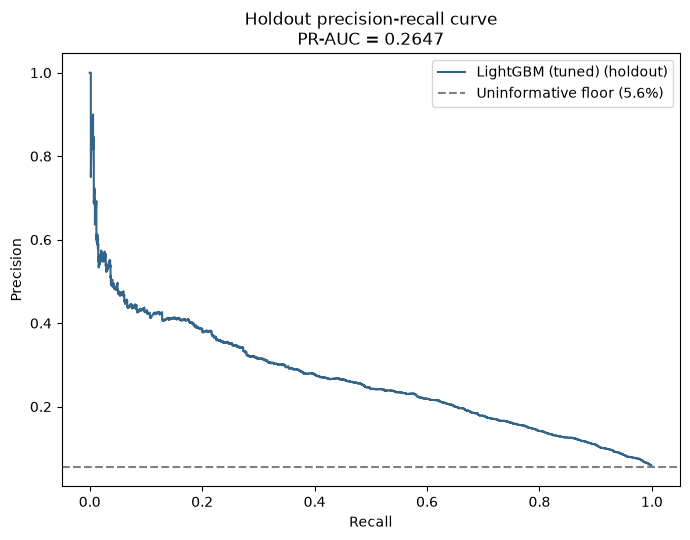

PR-AUC = 0.2647: the area under this curve, averaging precision across every possible recall level -- 4.7x the 5.6% floor an uninformative ranking would score on this same holdout.
ROC-AUC = 0.8354: in plain terms, if you picked one random fraud client and one random non-fraud client from the holdout, this model would rank the fraud client as riskier about 83.5% of the time.


In [9]:
holdout_base_rate = y_test_values.mean()
precisions, recalls, _ = precision_recall_curve(y_test_values, test_proba_final)

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(recalls, precisions, color="#33658A", label=f"{final_model_name} (holdout)")
ax.axhline(holdout_base_rate, linestyle="--", color="grey", label=f"Uninformative floor ({holdout_base_rate:.1%})")
ax.set(xlabel="Recall", ylabel="Precision",
       title=f"Holdout precision-recall curve\nPR-AUC = {holdout_pr_auc:.4f}")
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"PR-AUC = {holdout_pr_auc:.4f}: the area under this curve, averaging precision across every "
    f"possible recall level -- {holdout_pr_auc / holdout_base_rate:.1f}x the {holdout_base_rate:.1%} "
    "floor an uninformative ranking would score on this same holdout.\n"
    f"ROC-AUC = {holdout_roc_auc:.4f}: in plain terms, if you picked one random fraud client and one "
    f"random non-fraud client from the holdout, this model would rank the fraud client as riskier "
    f"about {holdout_roc_auc:.1%} of the time."
)

**In plain terms, for the client:**

- The model produces a genuinely informative ranking, not a coin flip: PR-AUC (0.2647) is
  roughly **4.7x** the floor an uninformative ranking would score at this fraud rate (5.6%), and
  ROC-AUC (0.8354) means a randomly chosen fraud client outranks a randomly chosen non-fraud
  client about 83.5% of the time.
- The curve above is a *menu*, not a verdict: every point on it is a different inspection-capacity
  choice -- fewer inspections at a higher hit rate, or more inspections that catch more fraud but
  waste more visits on false alarms. This notebook deliberately does not pick a point on that
  curve. Doing so requires knowing the team's actual inspection capacity and the relative cost of
  a missed fraud versus a wasted inspection, neither of which lives in this dataset -- that choice
  belongs to the client's operations team, not to this model. The one example worked out below
  makes a single point on this menu concrete, not chosen for them.
- Whatever point gets chosen, it should account for where this ranking is weaker: `04`'s error
  analysis found this model far less informative for short-history clients specifically -- a
  feature-availability gap (see Limitations) that this notebook's tuning doesn't address. A
  single global operating point will under-serve that group specifically, not just fall short on
  the aggregate.
- **Why PR-AUC, not ROC-AUC, is this project's headline metric** (`README.md`): with only 5.6% of
  clients labeled fraud, ROC-AUC can look strong even when a model isn't very useful for a
  capacity-limited inspection team, because it's dominated by how well the model ranks the (very
  common) non-fraud majority. PR-AUC weights the minority class more heavily and is the more
  honest number for judging usefulness on a problem shaped like this one.

### One concrete example, for scale (illustrative, not a recommendation)

Everything above is threshold-free on purpose. But "PR-AUC 0.2647" is hard to picture, so here is
**one** point on the curve above translated into plain counts -- flagging the top 10% highest-risk
holdout clients as an illustrative example, not because 10% is the right number for this client.
This reuses `test_proba_final`/`y_test_values` Step 7 already produced -- it is a different view
of that same one-time holdout score, not a new peek at the holdout, and not a second evaluation.
Picking any other share (5%, 20%, whatever the team's actual capacity is) would move every number
below along the same curve; the real choice still belongs to the client's operations team, per the
caveat above.

Confusion matrix at an illustrative top-10% cutoff:


,Actually fraud,Actually not fraud
Flagged for inspection,702,2008
Not flagged,811,23578


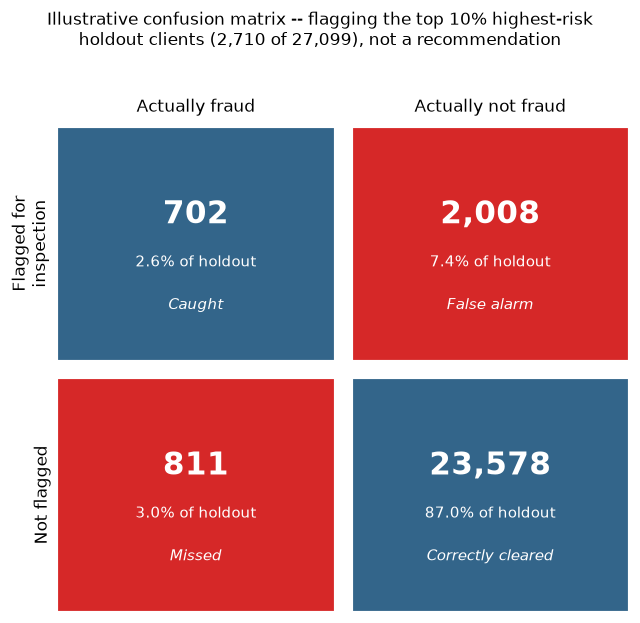

Illustrative example -- flagging the 2,710 highest-risk clients (10% of 27,099 holdout clients):
  Caught 702 of 1,513 real fraud cases (46.4%).
  Missed 811 real fraud cases (53.6%).
  Of the 2,710 clients flagged, 2,008 turned out not to be fraud (74.1% false-alarm rate) -- still 4.6x more concentrated with fraud than flagging clients at random.
This is ONE example point on the curve above, not a recommendation -- a different capacity or cost tradeoff would land on a different point on the same curve.


In [10]:
# ONE illustrative example, not a new evaluation: reuses test_proba_final/y_test_values Step 7
# already computed on the holdout -- just translated into a confusion matrix at a single
# illustrative capacity share, for readability. Not a recommendation (see the markdown above).
ILLUSTRATIVE_TOP_SHARE = 0.10

k_illustrative = int(np.ceil(ILLUSTRATIVE_TOP_SHARE * len(y_test_values)))
illustrative_threshold = np.sort(test_proba_final)[::-1][k_illustrative - 1]
illustrative_flagged = test_proba_final >= illustrative_threshold

caught = int((illustrative_flagged & (y_test_values == 1)).sum())
missed = int((~illustrative_flagged & (y_test_values == 1)).sum())
false_alarms = int((illustrative_flagged & (y_test_values == 0)).sum())
correctly_cleared = int((~illustrative_flagged & (y_test_values == 0)).sum())
total_holdout = caught + missed + false_alarms + correctly_cleared
total_fraud = caught + missed
total_flagged = caught + false_alarms
illustrative_recall = caught / total_fraud
illustrative_precision = caught / total_flagged
illustrative_lift = illustrative_precision / holdout_base_rate

confusion_table = pd.DataFrame(
    [[caught, false_alarms], [missed, correctly_cleared]],
    index=["Flagged for inspection", "Not flagged"],
    columns=["Actually fraud", "Actually not fraud"],
)
print(f"Confusion matrix at an illustrative top-{ILLUSTRATIVE_TOP_SHARE:.0%} cutoff:")
display(confusion_table)

# Presentation-ready confusion-matrix visual -- one Axes per cell (no imshow coordinate-flip risk).
# Correct calls (caught, correctly cleared) in blue, the two error types (missed, false alarm) in
# red -- a good/bad status coloring rather than a magnitude heatmap, since "correctly cleared"
# (by far the largest cell) would otherwise visually swamp the smaller, more decision-relevant ones.
CORRECT_COLOR = "#33658A"
ERROR_COLOR = "#D62828"

fig, axes = plt.subplots(2, 2, figsize=(6.5, 6))
cells = [
    (axes[0, 0], caught, "Caught", CORRECT_COLOR),
    (axes[0, 1], false_alarms, "False alarm", ERROR_COLOR),
    (axes[1, 0], missed, "Missed", ERROR_COLOR),
    (axes[1, 1], correctly_cleared, "Correctly cleared", CORRECT_COLOR),
]
for ax, count, label, color in cells:
    ax.set_facecolor(color)
    ax.text(0.5, 0.62, f"{count:,}", ha="center", va="center", transform=ax.transAxes,
             fontsize=22, fontweight="bold", color="white")
    ax.text(0.5, 0.42, f"{count / total_holdout:.1%} of holdout", ha="center", va="center",
             transform=ax.transAxes, fontsize=10.5, color="white")
    ax.text(0.5, 0.24, label, ha="center", va="center", transform=ax.transAxes,
             fontsize=11, color="white", style="italic")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor("white")
        spine.set_linewidth(3)

axes[0, 0].set_title("Actually fraud", fontsize=12, pad=10)
axes[0, 1].set_title("Actually not fraud", fontsize=12, pad=10)
axes[0, 0].set_ylabel("Flagged for\ninspection", fontsize=12)
axes[1, 0].set_ylabel("Not flagged", fontsize=12)

fig.suptitle(
    f"Illustrative confusion matrix -- flagging the top {ILLUSTRATIVE_TOP_SHARE:.0%} highest-risk\n"
    f"holdout clients ({total_flagged:,} of {total_holdout:,}), not a recommendation",
    fontsize=12, y=1.03,
)
plt.tight_layout()
plt.show()

print(
    f"Illustrative example -- flagging the {total_flagged:,} highest-risk clients "
    f"({ILLUSTRATIVE_TOP_SHARE:.0%} of {len(y_test_values):,} holdout clients):\n"
    f"  Caught {caught:,} of {total_fraud:,} real fraud cases ({illustrative_recall:.1%}).\n"
    f"  Missed {missed:,} real fraud cases ({1 - illustrative_recall:.1%}).\n"
    f"  Of the {total_flagged:,} clients flagged, {false_alarms:,} turned out not to be fraud "
    f"({1 - illustrative_precision:.1%} false-alarm rate) -- still {illustrative_lift:.1f}x more "
    "concentrated with fraud than flagging clients at random.\n"
    "This is ONE example point on the curve above, not a recommendation -- a different capacity "
    "or cost tradeoff would land on a different point on the same curve."
)

## Step 8 — Persist the frozen model for reuse

Everything above lives only in this kernel's memory: the fitted LightGBM estimator, the winning
hyperparameters, and the ensemble decision all vanish the moment this kernel restarts. That is
exactly what made re-verifying earlier edits to this notebook require a full ~45-minute rerun of
Step 4's search -- nothing about the tuned model outlived the session that produced it. This step
fixes that by saving the frozen recipe to disk once, here, so `06_model_application.ipynb` (and
any future notebook) can load it directly instead of re-deriving it -- and so **Step 4 above, the
next time this notebook runs, loads the same `winning_variant`/`best_params` straight back in and
skips the search entirely** (see Step 4's "Cached, so you don't pay for this twice" note).

Two files get saved to `models/`:

- **`final_model_pipeline.joblib`** -- the fitted pipeline(s), refit on *all* of `df_training`
  (development pool + `final_holdout` combined), not just the 80% development pool Steps 2-6
  used. The holdout's one job -- an honest, unpeeked-at check of the frozen recipe -- is already
  done by Step 7; nothing here changes the recipe itself (same preprocessing variant, same
  hyperparameters, same ensemble go/no-go). It only lets the model that actually gets deployed
  learn from every labelled client instead of leaving 20% of them unused.
- **`final_model_metadata.json`** -- the winning preprocessing variant, LightGBM
  hyperparameters, ensemble decision, feature lists, and the development/holdout metrics this
  notebook already established, so a downstream notebook can report them without needing to
  trust a stale docstring or a hardcoded number.

In [11]:
MODELS_DIR.mkdir(exist_ok=True)

# Refit the frozen recipe on every labelled client, not just the 80% development pool -- Step 7
# already spent the holdout's one job (an honest, unpeeked-at check of this exact recipe). This
# only gives the model that actually gets deployed more data to learn from. Nothing is re-tuned:
# clone(final_model_pipeline) (Step 4) carries over the exact same preprocessing variant and
# hyperparameters, and -- being a clone of the never-fitted template -- has no fitted state to
# leak in from anywhere. Using the same clone(...) pattern Step 4's OOF check already uses is
# also what makes this "the final model pipeline" and not a fourth, independently-typed copy of it.
X_full = df_training[model_features].copy()
if winning_variant == "native categorical":
    for col in categorical_features:
        X_full[col] = X_full[col].astype("category")
y_full = df_training["target"]

deployment_lightgbm = clone(final_model_pipeline)
deployment_lightgbm.fit(X_full, y_full)
deployment_artifacts = {"lightgbm": deployment_lightgbm}

if adopt_ensemble:
    deployment_rf = Pipeline([
        ("preprocess", clone(preprocessor_onehot)),
        ("model", RandomForestClassifier(class_weight="balanced", random_state=RSEED, n_jobs=-1)),
    ])
    deployment_rf.fit(df_training[model_features], y_full)
    deployment_artifacts["random_forest"] = deployment_rf

dump(deployment_artifacts, FINAL_MODEL_PATH)

final_model_metadata = {
    "final_model_name": final_model_name,
    "winning_variant": winning_variant,
    "best_params": best_params,
    "adopt_ensemble": bool(adopt_ensemble),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "model_features": model_features,
    "random_state": RSEED,
    "development_cv_pr_auc": float(final_dev_pr_auc),
    "holdout_pr_auc": float(holdout_pr_auc),
    "holdout_roc_auc": float(holdout_roc_auc),
    "holdout_base_rate": float(holdout_base_rate),
    "note": (
        "final_model_pipeline.joblib is refit on ALL labelled clients (development_data + "
        "final_holdout combined, via df_training) using this frozen recipe -- it is not the "
        "exact estimator Step 7 scored on the holdout (that one only ever saw the 80% "
        "development pool). holdout_pr_auc/holdout_roc_auc above are Step 7's one-time, honest "
        "evaluation of this recipe, and remain the best available estimate of how this "
        "deployment refit will perform on genuinely new clients."
    ),
}
with open(FINAL_METADATA_PATH, "w") as f:
    json.dump(final_model_metadata, f, indent=2)

print(
    f"Saved {'ensemble of ' + ', '.join(deployment_artifacts) if adopt_ensemble else 'tuned LightGBM'} "
    f"pipeline -> {FINAL_MODEL_PATH}"
)
print(f"Saved metadata -> {FINAL_METADATA_PATH}")
display(pd.Series(final_model_metadata["best_params"]).rename("value").to_frame())

Saved tuned LightGBM pipeline -> models/final_model_pipeline.joblib
Saved metadata -> models/final_model_metadata.json


,value
subsample,1.00
reg_lambda,5.00
reg_alpha,5.00
num_leaves,127.00
n_estimators,300.00
min_child_samples,50.00
max_depth,-1.00
learning_rate,0.03
colsample_bytree,1.00
